# Preprocessing

In [1]:
import nltk
from nltk.corpus import reuters, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import seaborn as sns
import html

In [2]:
dataset_1 = pd.read_csv('../data/FinalBalancedDataset.csv')
dataset_2 = pd.read_csv('../data/twitter_toxic_tweets.csv')

dataset_1 = dataset_1.rename(columns={'Toxicity': 'label'})

dataset_1 = dataset_1[['label', 'tweet']]
dataset_2 = dataset_2[['label', 'tweet']]

df = pd.concat([dataset_1, dataset_2], ignore_index=True)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


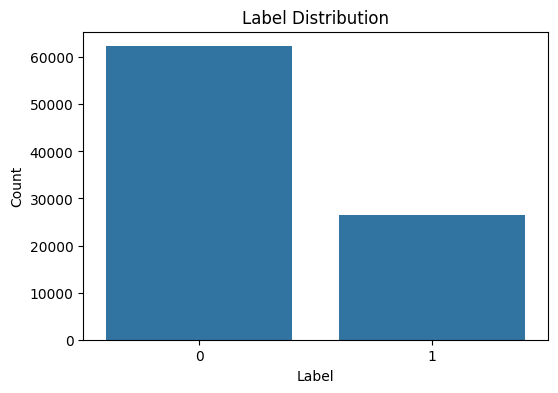

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [4]:
# Lowercase
df['tweet'] = df['tweet'].str.lower()
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [5]:
# Check if they have URL or HTML tags
have_url = df["tweet"].str.contains('http\S+|www\S+', regex=True).any()
have_html = df["tweet"].str.contains('<.*?>', regex=True).any()

print("Rows contain URL:", have_url)
print("Rows contain HTML:", have_html)

Rows contain URL: True
Rows contain HTML: False


<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Yohana\AppData\Local\Temp\ipykernel_15364\3178551942.py:2: SyntaxWarning: invalid escape sequence '\S'
  have_url = df["tweet"].str.contains('http\S+|www\S+', regex=True).any()


In [6]:
# Remove URL
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

df['tweet'] = df['tweet'].apply(remove_url)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [7]:
# Remove HTML entities like & (&amp;), < (&lt;), " (&quot;)
df['tweet'] = df['tweet'].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [8]:
# Remove @user before the @ is removed from removing the punctuation
def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

df['tweet'] = df['tweet'].apply(remove_mentions)
df.head()

,label,tweet
0,0,when a father is dysfunctional and is so sel...
1,0,thanks for #lyft credit i can't use cause th...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [9]:
# Remove punctuation
punc = string.punctuation   
def remove_punc(text):
    return text.translate(str.maketrans('', '', punc))

df['tweet'] = df['tweet'].apply(remove_punc)
df.head()

,label,tweet
0,0,when a father is dysfunctional and is so sel...
1,0,thanks for lyft credit i cant use cause they...
2,0,bihday your majesty
3,0,model i love u take with u all the time in u...
4,0,factsguide society now motivation


In [10]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Remove stopwords
def remove_stopwords(text):
    # Split text, keep word ONLY if it is not in stopwords
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

df['tweet'] = df['tweet'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,tweet
0,0,father dysfunctional selfish drags kids dysfun...
1,0,thanks lyft credit cant use cause dont offer w...
2,0,bihday majesty
3,0,model love u take u time urð± ðððð...
4,0,factsguide society motivation


In [11]:
# Remove emojis
def remove_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['tweet'] = df['tweet'].apply(remove_emoji)
df.head()

,label,tweet
0,0,father dysfunctional selfish drags kids dysfun...
1,0,thanks lyft credit cant use cause dont offer w...
2,0,bihday majesty
3,0,model love u take u time urð± ðððð...
4,0,factsguide society motivation


In [12]:
# Remove symbols and numbers
def remove_symbols(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['tweet'] = df['tweet'].apply(remove_symbols)
df.head()

,label,tweet
0,0,father dysfunctional selfish drags kids dysfun...
1,0,thanks lyft credit cant use cause dont offer w...
2,0,bihday majesty
3,0,model love u take u time ur
4,0,factsguide society motivation


In [13]:
from sklearn.utils import resample
max_size = df['label'].value_counts().max()
lst = [df[df['label'] == i] for i in df['label'].unique()]

df_balanced = pd.DataFrame()
for sub_df in lst:
    df_resampled = resample(sub_df, replace=True, n_samples=max_size, random_state=42)
    df_balanced = pd.concat([df_balanced, df_resampled])

print("Distribution after balancing:")
print(df_balanced['label'].value_counts())

Distribution after balancing:
label
0    62312
1    62312
Name: count, dtype: int64


In [14]:
# Tokenization
from nltk.tokenize import word_tokenize,sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

df_balanced['tweet'] = df_balanced['tweet'].apply(word_tokenize)
df_balanced.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,label,tweet
82381,0,"[future, melissa, theatre, asd, love]"
16981,0,"[people, like, nothing, contribute, get, kick,..."
930,0,"[friday, xoxosamantha, via]"
62728,0,"[sheer, waste, two, hours, watching, much, noi..."
80125,0,"[realytics, recrute, staup, jobs, tech, recrut..."


In [15]:
# Lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(word_list):
    return [lemmatizer.lemmatize(word) for word in word_list]

df_balanced['tweet'] = df_balanced['tweet'].apply(lemmatize_text)
df_balanced.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Yohana\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,label,tweet
82381,0,"[future, melissa, theatre, asd, love]"
16981,0,"[people, like, nothing, contribute, get, kick,..."
930,0,"[friday, xoxosamantha, via]"
62728,0,"[sheer, waste, two, hour, watching, much, nois..."
80125,0,"[realytics, recrute, staup, job, tech, recrute..."


In [16]:
# Final Check of Top 20 Most Common Words
all_words = [word for sublist in df_balanced['tweet'] for word in sublist]

word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)

print('\nMost common words:')
for word, count in most_common_words:
    print(f'{word}: {count}')


Most common words:
bitch: 26947
rt: 17015
hoe: 10141
like: 8804
im: 7295
love: 7267
u: 6929
day: 6633
dont: 5696
get: 5647
pussy: 5312
got: 4910
nigga: 4768
as: 3897
fuck: 3822
happy: 3811
time: 3665
one: 3357
shit: 3332
cant: 3267


# Visualization

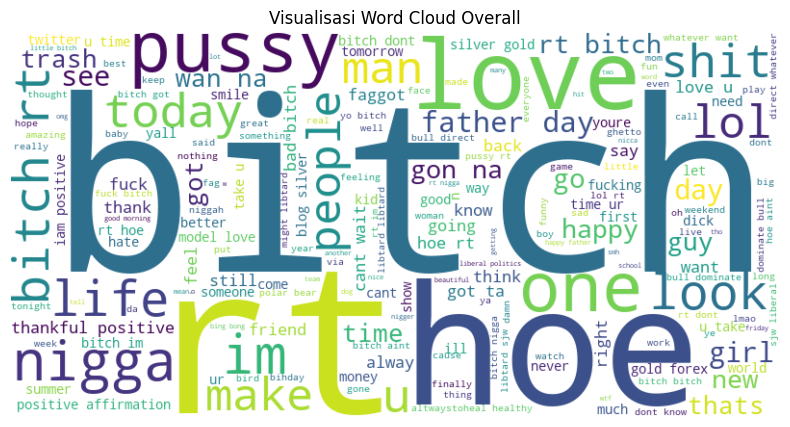

In [17]:
# Word Cloud
def plot_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Visualisasi Word Cloud Overall")
    plt.show()

all_words = []

for tokens in df_balanced['tweet']:
    all_words.extend(tokens)

plot_wordcloud(" ".join(all_words))

In [18]:
df_balanced.to_csv('../data/preprocessed_result_260304_01.csv', index=False, encoding='utf-8')